<a href="https://colab.research.google.com/github/narenderkulariya/st20269341-CMP7005-PRAC1/blob/main/model_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Importing the required packages**


In [1]:
import numpy as np                               # Importing NumPy for numerical operations and working with arrays
import pandas as pd                              # Importing pandas for handling and analyzing tabular data (DataFrames)
from sklearn.impute import SimpleImputer         # Importing SimpleImputer to fill missing values in the dataset
from sklearn.model_selection import train_test_split  # Importing function to split data into training and testing sets
from sklearn.ensemble import RandomForestRegressor    # Importing Random Forest Regressor model for predicting numeric values (e.g., AQI)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score  # Importing metrics to evaluate how good the model's predictions are
import joblib                                    # Importing joblib to save and load trained models to/from files


In [2]:
df = pd.read_csv('/content/drive/MyDrive/CMP7005/all_cities_combined_cleaned.csv')

## **Train-test data preparation**

In [3]:
X = df[['PM2.5','PM10','NO','NO2','NOx','NH3','CO','SO2','O3','Benzene','Toluene','Xylene']]
# Selecting pollutant columns from df to use as features (inputs) and store them in X
y = df['AQI']
# Selecting the AQI column from df as the target variable (output) and store it in y


⬆️ All the pollutant columns are put into X as the data the model will learn from, and the AQI column is put into y as the value the model should predict.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(   # Spliting the data into training and test sets
    X,                                                 # Featuring data (inputs: pollutant columns)
    y,                                                 # Target data (output: AQI values)
    test_size=0.2,                                     # Using 20% of the data for testing and 80% for training
    random_state=42                                    # Fixing the random seed so the split is the same every time you run it
)


⬆️ The code divides the dataset into two parts: one part to train the model and another smaller part to test how well the model works later.

In [5]:
model = RandomForestRegressor(n_estimators=200, random_state=42)
# Creating a Random Forest model with 200 trees and a fixed random seed for reproducible results
model.fit(X_train, y_train)
# Train (fit) the model using the training data: features X_train and targets y_train


RandomForestRegressor(n_estimators=200, random_state=42)

⬆️ A Random Forest regression model with 200 trees is set up, and then it is trained using the training data so it can learn the relationship between pollutants and AQI.

In [6]:
y_pred = model.predict(X_test)
# Using the trained model to predict AQI values for the unseen test features X_test and store them in y_pred


In [7]:
joblib.dump(model, '/content/drive/MyDrive/CMP7005/model.pkl')

['/content/drive/MyDrive/CMP7005/model.pkl']

## **Model evaluation**

In [8]:
mae = mean_absolute_error(y_test, y_pred)   # Calculating MAE: average absolute difference between real values and predicted values
mse = mean_squared_error(y_test, y_pred)    # Calculating MSE: average of squared differences between real and predicted values
rmse = np.sqrt(mse)                         # Calculating RMSE: square root of MSE, error in the original units of the target
r2 = r2_score(y_test, y_pred)               # Calculating R²: how much of the variation in the target is explained by the model

print("MAE  :", mae)                        # Print the Mean Absolute Error
print("MSE  :", mse)                        # Print the Mean Squared Error
print("RMSE :", rmse)                       # Print the Root Mean Squared Error
print("R²   :", r2)                         # Print the R-squared score


MAE  : 19.914242580129283
MSE  : 1698.162952624196
RMSE : 41.208772762898384
R²   : 0.8886533125331232


⬆️ The code measures the error between the true values (y_test) and the model’s predictions (y_pred) using four metrics (MAE, MSE, RMSE, R²) and then shows these numbers so the model’s performance can be understood.

**MAE : 19.914242580129283**

on average, the model’s AQI prediction is about 20 units away from the true AQI.

**MSE : 1698.162952624196**

This is the average of the squared errors; higher than MAE because errors are squared.

**RMSE : 41.208772762898384**

This is like the average error in the same AQI units; here the typical error is about 41 AQI points.

**R² : 0.8886533125331232**

the model explains about 88.9% of the variation in AQI, which indicates a strong fit.

# **Visualisation**

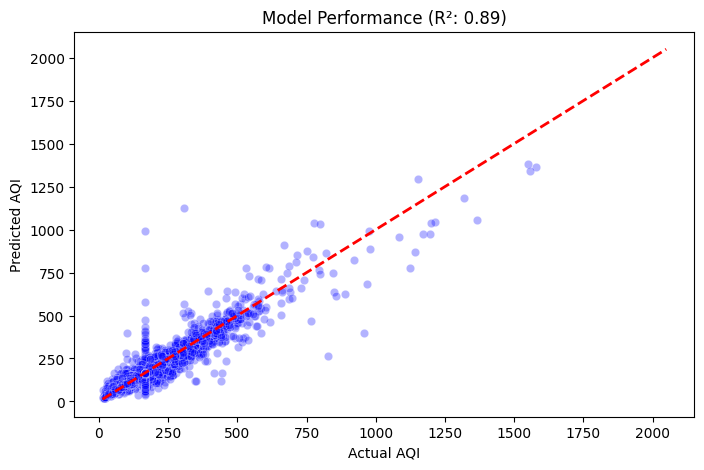

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
# Visual Proof (Actual vs Predicted)
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.3, color='blue')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title(f"Model Performance (R²: {r2:.2f})")
plt.show()

⬆️ **Points close to the line:** Each blue dot represents an actual AQI value and the AQI value predicted by model. The closer these dots are to the red dashed line, the more accurate the prediction.

**R² score (0.89):** This number tells us that model explains about 89% of the changes in the actual AQI. A higher R² value means the model is better at capturing the patterns in the data and making accurate predictions.